Step 1: Preparation (Accounts Needed)


To use this script effectively, you and your researchers need the following:

SerpAPI Key: * What for: To search Google Scholar.

Where: Create an account at serpapi.com. You get 100 free searches per month.

Semantic Scholar API Key (Optional but Recommended):

What for: To pull the "TLDR" (AI-summary) and full abstracts.

Where: Apply for a free key at semanticscholar.org/product/api. Without a key, you are limited to 1 request per second.

1) Setup & Dependencies

In [27]:
# Install the necessary libraries
!pip install google-search-results pandas requests matplotlib

Save persistently

In [39]:
# --- IN YOUR SETUP CELL ---
from google.colab import drive
import os

# Mount your drive
drive.mount('/content/drive')

# Create a specific folder for your EEG research if it doesn't exist
# This keeps your Drive organized
research_path = "/content/drive/MyDrive/Research/EEG_Bias_Reviews"
if not os.path.exists(research_path):
    os.makedirs(research_path)
    print(f"📁 Created new directory: {research_path}")

Mounted at /content/drive
📁 Created new directory: /content/drive/MyDrive/Research/EEG_Bias_Reviews


2) Secure Configuration & API Keys

In [40]:
import pandas as pd
import requests
import time
import random
import re
from datetime import datetime
from google.colab import userdata
from serpapi import GoogleSearch

# Retrieve keys securely
SERP_API_KEY = userdata.get('SERP_API_KEY')
S2_API_KEY = userdata.get('S2_API_KEY')

# Search parameters for your EEG review
QUERY = '("EEG" OR "BCI") AND ("melanin" OR "hair texture") AND "bias"'
LIMIT = 50  # Total papers to collect

# Generate a timestamp for the run
run_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
file_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") # For sortable filename

3) The Robust API Engine

This function handles both search and batch metadata retrieval. It includes the exponential backoff logic to prevent crashes.

In [41]:
def s2_request(url, method="GET", params=None, json_data=None, max_retries=5):
    """Handles authenticated/unauthenticated requests with exponential backoff."""
    headers = {"x-api-key": S2_API_KEY} if S2_API_KEY else {}
    base_delay = 1.1 if S2_API_KEY else 3.1 # Authenticated is faster

    for attempt in range(max_retries):
        try:
            if method == "POST":
                response = requests.post(url, params=params, json=json_data, headers=headers, timeout=20)
            else:
                response = requests.get(url, params=params, headers=headers, timeout=20)

            if response.status_code == 200:
                return response.json()

            if response.status_code == 429: # Rate limited
                wait = (base_delay * (2 ** attempt)) + random.uniform(0, 1)
                print(f"⏳ Rate limit hit. Waiting {wait:.2f}s...")
                time.sleep(wait)
            else:
                print(f"❌ API Error {response.status_code}")
                break
        except Exception as e:
            print(f"📡 Network error: {e}")
            time.sleep(base_delay)
    return None

def categorize_focus(row):
    """Categorizes paper based on content keywords."""
    text = f"{row['Title']} {row['Abstract']}".lower()
    if any(x in text for x in ['electrode', 'impedance', 'hair', 'melanin', 'contact']):
        return "Hardware/Physics"
    if any(x in text for x in ['cnn', 'algorithm', 'dataset', 'fairness', 'training']):
        return "Algorithmic/AI"
    return "General/Clinical"

4) Systematic Search & Batch Enrichment

In [42]:
def run_lit_review_pipeline():
    # 1. Generate Metadata for this specific run
    run_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    file_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    print(f"🚀 Starting search: {QUERY} at {run_timestamp}")

    search = GoogleSearch({"engine": "google_scholar", "q": QUERY, "api_key": SERP_API_KEY, "num": 20})
    results = search.get_dict().get("organic_results", [])

    final_papers = []
    for res in results[:LIMIT]:
        title = res.get("title")
        meta = get_paper_data(title)

        final_papers.append({
            "Search_Query": QUERY,          # Persistent record of logic used
            "Search_Timestamp": run_timestamp, # Date of data retrieval
            "Title": title,
            "Citations": res.get("inline_links", {}).get("cited_by", {}).get("total", 0),
            "Link": res.get("link"),
            **meta
        })

    df = pd.DataFrame(final_papers)

    if not df.empty:
        df['Category'] = df.apply(categorize_focus, axis=1)

        # Save to Google Drive
        filename = f"EEG_Review_{file_timestamp}.csv"
        full_save_path = f"{research_path}/{filename}"
        df.to_csv(full_save_path, index=False)

        print(f"✅ Version saved to Drive: {full_save_path}")
        return df, full_save_path
    return pd.DataFrame(), None

5) Summary & Analysis

In [43]:
def get_paper_data(title):
    search_url = "https://api.semanticscholar.org/graph/v1/paper/search"
    # Requesting specific fields for code, datasets, and open access
    fields = "title,abstract,tldr,openAccessPdf,year,citationCount,externalIds,publicationTypes"
    params = {"query": title, "limit": 1, "fields": fields}

    # Call the correctly named function 's2_request'
    data = s2_request(search_url, params=params)

    if data and data.get('data'):
        paper = data['data'][0]
        if paper: # Added check to ensure paper is not None
            abstract = paper.get("abstract") or ""
            tldr = (paper.get("tldr") or {}).get("text") or ""

            # Heuristic for Code/Data discovery
            text_to_scan = (abstract + " " + tldr).lower()
            has_code = "YES" if any(x in text_to_scan for x in ['github', 'gitlab', 'code available', 'repository']) else "No"
            has_data = "YES" if any(x in text_to_scan for x in ['dataset', 'zenodo', 'data available', 'figshare']) else "No"

            return {
                "Abstract": abstract,
                "TLDR": tldr,
                "OpenAccess": "Yes" if paper.get("openAccessPdf") else "No",
                "HasCode": has_code,
                "HasData": has_data,
                "S2ID": paper.get("paperId")
            }
    return {"Abstract": "N/A", "TLDR": "N/A", "OpenAccess": "N/A", "HasCode": "N/A", "HasData": "N/A"}

def categorize_paper(row):
    text = f"{row['Title']} {row['Abstract']}".lower()
    if any(x in text for x in ['electrode', 'impedance', 'hair', 'melanin']): return "Hardware/Physics"
    if any(x in text for x in ['cnn', 'algorithm', 'fairness', 'training']): return "Algorithmic/AI"
    return "General/Clinical"

6) Execution & Export

In [44]:
def run_lit_review_pipeline():
    print(f"🚀 Starting systematic search for: {QUERY}")

    # 1. Search Google Scholar via SerpAPI
    # We use SerpAPI for the initial search because it's the best for "relevance"
    search = GoogleSearch({"engine": "google_scholar", "q": QUERY, "api_key": SERP_API_KEY, "num": 20})
    organic_results = search.get_dict().get("organic_results", [])

    if not organic_results:
        print("🛑 No results found. Check your SerpAPI key or Query logic.")
        return pd.DataFrame()

    final_papers = []
    # Limit to the number of papers you actually want to process
    for res in organic_results[:LIMIT]:
        title = res.get("title")
        print(f"📄 Processing: {title[:60]}...")

        # 2. Enrich with Semantic Scholar
        # This uses our robust, backoff-enabled function
        meta = get_paper_data(title)

        # 3. Combine Google data with Semantic Scholar data
        paper_entry = {
            "Title": title,
            "Year": re.search(r'\d{4}', res.get("publication_info", {}).get("summary", "")).group() if re.search(r'\d{4}', res.get("publication_info", {}).get("summary", "")) else "N/A",
            "Citations": res.get("inline_links", {}).get("cited_by", {}).get("total", 0),
            "Link": res.get("link"),
            "Category": "", # Place holder
            **meta # Unpacks Abstract, TLDR, OpenAccess, etc.
        }
        final_papers.append(paper_entry)

    # 4. Final Processing & Export
    df = pd.DataFrame(final_papers)

    if not df.empty:
        df['Category'] = df.apply(categorize_focus, axis=1)
        filename = "EEG_Bias_Final_Review.csv"
        df.to_csv(filename, index=False)
        print(f"\n✅ Success! {len(df)} papers saved to {filename}")
        return df
    return pd.DataFrame()

# --- EXECUTE EVERYTHING ---
df_final = run_lit_review_pipeline()
if not df_final.empty:
    display(df_final.head())

🚀 Starting systematic search for: ("EEG" OR "BCI") AND ("melanin" OR "hair texture") AND "bias"
📄 Processing: Assessing Field Standard Practices for Incorporating Black I...
📄 Processing: Racial Bias in EEG Research​...
📄 Processing: Hair me out: Highlighting systematic exclusion in psychophys...
⏳ Rate limit hit. Waiting 1.16s...
⏳ Rate limit hit. Waiting 3.16s...
📄 Processing: psychophysiological methods...
📄 Processing: Fostering inclusion in EEG measures of pediatric brain activ...
📄 Processing: The effect of hair type and texture on electroencephalograph...
📄 Processing: Testing the Universal Electroencephalography Clip to correct...
📄 Processing: Untangling bias: Racial and phenotypic bias in neuroimaging ...
📄 Processing: Inclusivity in fNIRS studies: quantifying the impact of hair...
⏳ Rate limit hit. Waiting 1.63s...
📄 Processing: Addressing racial and phenotypic bias in human neuroscience ...
📄 Processing: See You Never: Exclusion in Electroencephalography and Neuro...
📄 Proc

,Title,Year,Citations,Link,Category,Abstract,TLDR,OpenAccess,HasCode,HasData,S2ID
0,Assessing Field Standard Practices for Incorpo...,2023,2,https://search.proquest.com/openview/61f095f4d...,General/Clinical,,Two innovative tools: VR-JIT and KF-STRIDE suc...,Yes,No,No,3f48980b0cdb4ebac7366d251c19fd39557cf435
1,Racial Bias in EEG Research​,N/A,0,http://www.theharvardbrain.com/spring-2023-eva...,Hardware/Physics,Racial disparities in maternal health are alar...,Electroencephalography/ERP researchers who stu...,Yes,No,No,7e45e07854b185feb589aa6542c6831a3dc52107
2,Hair me out: Highlighting systematic exclusion...,2022,36,https://www.frontiersin.org/journals/human-neu...,Hardware/Physics,"COPYRIGHT © 2022 Louis, Webster, Gloe and Mose...",Hair me out: Highlighting systematic exclusion...,Yes,No,No,39d7255de3c55828b8d9f1783ce6e75c2668e16d
3,psychophysiological methods,2025,0,https://books.google.com/books?hl=en&lr=&id=Tt...,Algorithmic/AI,This paper describes characteristics of sophis...,,Yes,No,No,d68fc3df5d0a3dc69534c2e7262224c36e1e2357
4,Fostering inclusion in EEG measures of pediatr...,2024,27,https://www.nature.com/articles/s41539-024-002...,Hardware/Physics,The past two decades have seen a rapid increas...,A comprehensive review of how cultural conside...,Yes,No,No,336ce558aef74329c8c7819421c5f2e6abaf4b2e


7) The Research Insights Cell

📊 --- RESEARCH INSIGHTS SUMMARY --- 📊

📖 Open Access Papers: 16 (80.0%)
💻 Papers with Code Hints: 0
📂 Papers with Data Hints: 1
----------------------------------------
🎯 Research Focus Distribution:
Category
Hardware/Physics    10
General/Clinical     9
Algorithmic/AI       1
Name: count, dtype: int64
----------------------------------------
🌟 Top 3 Highly Cited Papers in this Batch:
- Addressing racial and phenotypic bias in human neuroscience methods (2022) | 127 citations
- Demographic reporting and phenotypic exclusion in fNIRS (2023) | 73 citations
- Structural racism in neuroimaging: perspectives and solutions (2022) | 47 citations


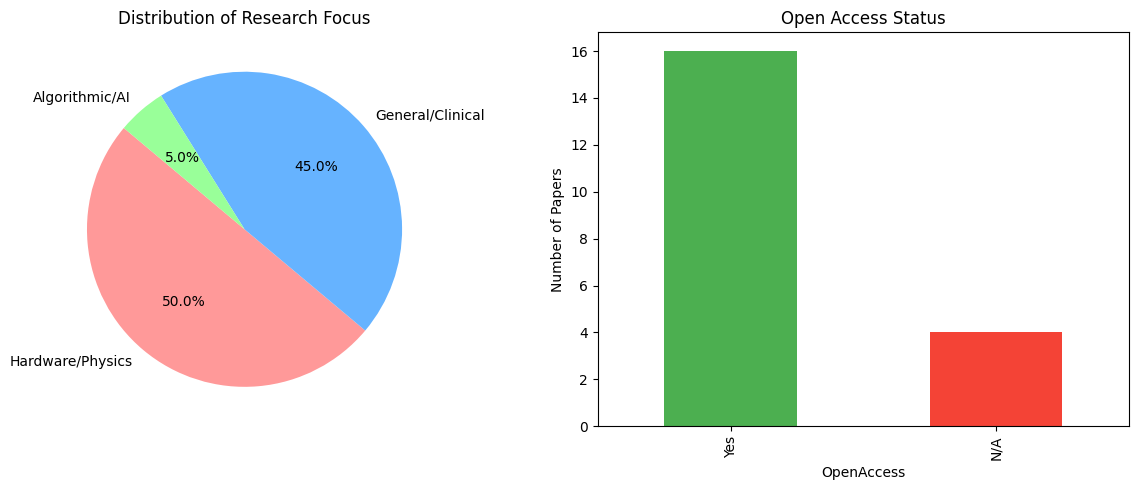

In [45]:
import matplotlib.pyplot as plt

def generate_research_summary(df):
    if df.empty:
        print("⚠️ No data to summarize.")
        return

    print("📊 --- RESEARCH INSIGHTS SUMMARY --- 📊\n")

    # 1. Open Access & Resource Availability
    oa_count = df['OpenAccess'].value_counts().get('Yes', 0)
    code_count = df['HasCode'].str.upper().value_counts().get('YES', 0)
    data_count = df['HasData'].str.upper().value_counts().get('YES', 0)

    print(f"📖 Open Access Papers: {oa_count} ({oa_count/len(df)*100:.1f}%)")
    print(f"💻 Papers with Code Hints: {code_count}")
    print(f"📂 Papers with Data Hints: {data_count}")
    print("-" * 40)

    # 2. Categorical Distribution
    print("🎯 Research Focus Distribution:")
    print(df['Category'].value_counts())
    print("-" * 40)

    # 3. Top Influential Papers (Most Cited)
    print("🌟 Top 3 Highly Cited Papers in this Batch:")
    top_papers = df.nlargest(3, 'Citations')
    for i, row in top_papers.iterrows():
        print(f"- {row['Title']} ({row['Year']}) | {row['Citations']} citations")

    # 4. Simple Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Pie chart of Focus
    df['Category'].value_counts().plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
    ax1.set_title("Distribution of Research Focus")
    ax1.set_ylabel("")

    # Bar chart of Open Access
    df['OpenAccess'].value_counts().plot(kind='bar', ax=ax2, color=['#4CAF50', '#F44336'])
    ax2.set_title("Open Access Status")
    ax2.set_ylabel("Number of Papers")

    plt.tight_layout()
    plt.show()

# Run the summary
generate_research_summary(df_final)

8) The "New Paper" Comparator Function

This function is essential for long-term reviews. It compares your latest run against a "Master" list (or a previous version) and isolates only the papers you haven't seen before based on their Title.

In [47]:
def find_new_discoveries(new_df, previous_csv_path):
    """
    Compares the new search results against a previous CSV file.
    Returns only the rows that appear in the new search but not the old one.
    """
    if not os.path.exists(previous_csv_path):
        print("⚠️ No previous file found to compare. All papers are considered 'New'.")
        return new_df

    # Load previous data
    old_df = pd.read_csv(previous_csv_path)

    # Identify unique papers using the Title column
    # We use a 'left join' and check for nulls in the right side
    merged = new_df.merge(old_df[['Title']], on='Title', how='left', indicator=True)
    new_discoveries = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])

    print(f"✨ New Papers Discovered: {len(new_discoveries)} out of {len(new_df)} total results.")
    return new_discoveries

# Example Usage:
# latest_df, latest_path = run_lit_review_pipeline()
# new_stuff = find_new_discoveries(latest_df, "path/to/previous_version.csv")